# CS of nucleating mode

In [144]:
import glob
import xarray as xr
from sklearn.linear_model import LinearRegression
import math
import datetime 
import matplotlib.pyplot as plt
import numpy as np
from xarray.plot.utils import _infer_interval_breaks as infer_interval_breaks
import pandas as pd
import os
import matplotlib.dates as dts
from matplotlib.colors import LogNorm, Normalize
import matplotlib.dates as md
import numpy as np
import glob
import pandas as pd
from datetime import datetime, timedelta
import re
from pathlib import Path

plt.rcParams["font.family"] = 'monospace'

In [145]:
# Define paths relative to notebook location
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
analysis_file_path = project_root / 'Analysis' 
plots_outpath = project_root / 'Plots'

In [146]:
def save_plot(fig, filepath, dpi=300):
    """
    Save figure to file with automatic directory creation.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save
    filepath : str or Path
        Full path where to save the figure (e.g., 'path/to/figure.jpeg')
    dpi : int, optional
        Resolution in dots per inch (default: 300)
    """
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(filepath, bbox_inches='tight', dpi=dpi)
    print(f"Saved: {filepath}")

In [4]:
def from_Dp2lDp(o: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset,
xr.DataArray]:
    """
    Convert particle diameter to log10(particle diameter)

    Parameters
    ----------
    o : xr.Dataset
        Dataset with a 'Dp' variable

    Returns
    -------
    xr.Dataset
        Dataset with a 'lDp' variable added,
        where 'lDp' is the base-10 logarithm of 'Dp'.
    """
    lDp = np.log10(o['Dp'])
    o = o.assign_coords({'lDp': lDp})
    return o

def set_lDp(o):
    dims = list(o.dims)
    coords = list(o.coords)
    # o_coords = set(coords)-set(dims)
    if 'lDp' not in coords:
        o = from_Dp2lDp(o)
    if 'lDp' not in dims:
        o = o.swap_dims({'Dp': 'lDp'})
    return o

def dp_regrid(da, *, n_subs, log_dy):

    if isinstance(da, xr.DataArray):
        assert da.name == 'dndlDp'
        da_ = da
    elif isinstance(da, xr.Dataset):
        da_ = da['dndlDp']

    # Keep original time coordinate
    time = da_.time

    # Convert Dp -> lDp
    ds1 = set_lDp(da_).reset_coords(drop=True)

    # Fine-grid spacing
    dy = log_dy / n_subs

    # Original lDp interval boundaries
    ints = infer_interval_breaks(
        ds1['lDp'],
        check_monotonic=True
    )

    ym_ = float(ints[0])
    yM_ = float(ints[-1])

    # Align fine grid with dy
    ym = np.round(ym_ / dy) * dy
    yM = np.round(yM_ / dy) * dy

    # Fine lDp grid
    yl = np.arange(
        ym,
        yM + dy / 2,
        dy
    )

    # Interpolate
    d1 = ds1.interp(
        lDp=yl,
        kwargs=dict(fill_value="extrapolate")
    )

    # Number of complete output bins
    n_bins = len(yl) // n_subs

    # Discard incomplete final bin
    d1 = d1.isel(
        lDp=slice(0, n_bins * n_subs)
    )

    # ---------------------------------------------------------
    # Reshape:
    #
    # (time, fine_lDp)
    #
    #        ↓
    #
    # (time, lDp_bin, sub)
    # ---------------------------------------------------------

    values = d1.values.reshape(
        len(time),
        n_bins,
        n_subs
    )

    # Mean over subintervals
    values = values.mean(axis=2)

    # Output lDp coordinates
    lDp = (
        ym
        + (np.arange(n_bins) + 0.5) * log_dy
    )

    # Construct output explicitly
    dsout = xr.DataArray(
        values,
        dims=('time', 'lDp'),
        coords={
            'time': time,
            'lDp': lDp,
        },
        name='dndlDp',
        attrs=da_.attrs,
    )

    return dsout

def from_lDp2Dp(o: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset,
xr.DataArray]:
    """
    Convert log10(particle diameter) to particle diameter

    Parameters
    ----------
    o : xr.Dataset
        Dataset with a 'lDp' variable

    Returns
    -------
    xr.Dataset
        Dataset with a 'Dp' variable added,
        where 'Dp' is the base-10 exponential of 'lDp'.
    """
    Dp = 10 ** (o['lDp'])
    o = o.assign_coords({'Dp': Dp})
    return o


def set_sec(o):
    dims = list(o.dims)
    coords = list(o.coords)
    # o_coords = set(coords)-set(dims)
    if 'secs' not in coords:
        o = from_time2sec(o)
    if 'secs' not in dims:
        o = o.swap_dims({'time': 'secs'})
    return o

def from_sec2time(o: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset, xr.DataArray]:
    """
    Convert seconds since 1970-01-01 to time

    Parameters
    ----------
    o : Union[xr.Dataset, xr.DataArray]
        DataArray or Dataset with a 'secs' coordinate

    Returns
    -------
    Union[xr.Dataset, xr.DataArray]
        DataArray or Dataset with a 'time' coordinate added,
        where 'time' is the date and time corresponding to the
        number of seconds since 1970-01-01.
    """
    secs = o['secs'].astype('datetime64[s]')
    o = o.assign_coords({'time': secs})
    return o

def from_time2sec(o: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset, xr.DataArray]:
    """
    Convert time to seconds since 1970-01-01

    Parameters
    ----------
    o : Union[xr.Dataset, xr.DataArray]
        DataArray or Dataset with a 'time' coordinate

    Returns
    -------
    Union[xr.Dataset, xr.DataArray]
        DataArray or Dataset with a 'secs' coordinate added,
        where 'secs' is the time in seconds since 1970-01-01.
    """
    date = o['time']
    # handle numeric time coordinates (already seconds) or datetime64 with various units
    vals = date.values
    # numeric type: assume seconds since epoch already
    if np.issubdtype(vals.dtype, np.number):
        secs = vals.astype('float64')
    else:
        # try to compute seconds since UNIX epoch robustly
        try:
            epoch = np.datetime64('1970-01-01T00:00:00')
            secs = (vals - epoch) / np.timedelta64(1, 's')
        except Exception:
            # fallback: use pandas to_datetime then convert to seconds
            try:
                secs = pd.to_datetime(vals).astype('int64') / 1e9
            except Exception:
                # last resort: attempt matplotlib date2num then convert days to seconds
                try:
                    import matplotlib.dates as mdates
                    secs = (mdates.date2num(vals) - mdates.date2num(np.datetime64('1970-01-01'))) * 86400.0
                except Exception:
                    raise ValueError('Unsupported time coordinate dtype for from_time2sec: %s' % (vals.dtype,))

    # assign secs coordinate aligned with the time dimension
    o = o.assign_coords({'secs': (date.dims, secs)})
    return o

def set_time(o):
    dims = list(o.dims)
    coords = list(o.coords)
    # o_coords = set(coords)-set(dims)

    if 'time' not in coords:
        o = from_sec2time(o)

    if 'time' not in dims:
        o = o.swap_dims({'secs': 'time'})

    return o

def set_Dp(o):
    dims = list(o.dims)
    coords = list(o.coords)
    if 'Dp' not in coords:
        # print(coords)
        o = from_lDp2Dp(o)
    if 'Dp' not in dims:
        o = o.swap_dims({'lDp': 'Dp'})
    return o

def upsample_ts(o, dt):
    dt = float(dt)
    orgi_dt = set_sec(o)['secs'].diff('secs').mean().item()
    assert dt <= orgi_dt, 'you are trying to upsample when you should be downsampling'
    orig_dim = list(o.dims)
    print('original dims:', orig_dim)
    o = set_time(o)
    o = o.resample({'time': pd.Timedelta(dt, unit='s')}).interpolate('linear')
    if 'time' in orig_dim:
        o = set_time(o)
    if 'secs' in orig_dim:
        o = set_sec(o)
    return o

def rename_resample_xr(XR_resampled, polarity='neg', mode='particles', resolution='15T', 
                           average='median'):
    xr_nais = XR_resampled[str(polarity)+'_'+str(mode)].to_pandas()
    #resample to 15 minutes
    if average == 'mean':
        ds_ = xr_nais.stack().to_xarray().rename({'diameter':'Dp'}).assign_coords({'Dp':lambda d:d['Dp'].astype(float)}).rename('dndlDp').sortby('time').resample({'time':resolution}).mean()
    if average == 'median':
        ds_ = xr_nais.stack().to_xarray().rename({'diameter':'Dp'}).assign_coords({'Dp':lambda d:d['Dp'].astype(float)}).rename('dndlDp').sortby('time').resample({'time':resolution}).median()
    ds_.drop_duplicates(dim='time')
    return ds_

def regrid_ds(ds_):
    ## regridding ppsamples a time series with a given time step. Regrids the diameter distribution of 40 to 27
    ds = (ds_.pipe(dp_regrid, log_dy=.05, n_subs=10).pipe(set_Dp))    
    return ds

def interpolate_ds(ds, minutes=15):
    ds=ds.pipe(upsample_ts, dt=minutes*60) #linear interpolation
    ds = ds.to_dataset()
    return ds

In [5]:
########### LOAD 5 MINUTE NAIS DATA ####################################################################
resolution = '5min'
path = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\resampled\resampled_removed_snow_clouds_bad_charged'
XR_resampled = xr.open_dataset(path+'\\'+str(resolution)+'_removed_snow_clouds_bad_charged.nc')
polarity='neg';
mode='particles'

In [17]:
########## REGRID AND INTERPOLATE 5 MINUTE NAIS DATA TO 15 MINUTES ####################################################################
ds_nais_neg = rename_resample_xr(XR_resampled, polarity='neg', mode='particles', 
                             resolution='15min', average='median')

ds_nais_neg = regrid_ds(ds_nais_neg)
ds_nais_neg =  interpolate_ds(ds_nais_neg, minutes=15)

ds_nais_neg = ds_nais_neg.drop_vars('lDp')
ds_nais_neg = ds_nais_neg.loc[{'time':slice('2022-04-17','2024-10-04')}]
ds_nais_neg = ds_nais_neg.expand_dims(id=["nais"])

original dims: ['time', 'Dp']


In [7]:
# #get clean particles
# resolution = '5T'
# path = r'C:/Users/DominicHeslinRees/NAIS_work/ZEP_processed_files/resampled_removed_snow_clouds_bad_charged/'
# XR_resampled = xr.open_dataset(path+'\\'+str(resolution)+'_removed_snow_clouds_bad_charged.nc')

# polarity='neg';
# mode='particles'
# ds_nais_neg = regrid_resample_addid_save_file(XR_resampled, current_dir=current_dir, polarity=polarity, 
#                                                 mode=mode, resample = '15T', average='median')
# ds_nais_neg = ds_nais_neg.drop('lDp')
# ds_nais_neg = ds_nais_neg.loc[{'time':slice('2022-04-17','2024-10-04')}]

# save events: 

In [112]:
event_times_loadpath = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\event_times'
filename='events_start_and_end_times_checked.xlsx' 

df_NPF_plusgrowth = pd.read_excel(event_times_loadpath+'\\'+filename, index_col=0, parse_dates=True)
df_NPF_plusgrowth.index.name = 'event'

df_NPF_plusgrowth['start_date'] = df_NPF_plusgrowth['start_event'].dt.date
df_NPF_plusgrowth['start_date'] = df_NPF_plusgrowth['start_date'].astype(str)
df_NPF_plusgrowth['end_date'] = df_NPF_plusgrowth['end_event'].dt.date
df_NPF_plusgrowth['end_date'] = df_NPF_plusgrowth['end_date'].astype(str)

date='2022-04-18'
df_NPF_plusgrowth[df_NPF_plusgrowth['start_date'] == str(date)]

,start_event,end_event,event_class,comments,start_date,end_date
event,,,,,,
2022-04-18,2022-04-18 06:25:00,2022-04-19 03:00:00,Class II,NaN,2022-04-18,2022-04-19


In [12]:
def slice_by_time(ds, start_time, end_time):
    ds = ds.sel(time=slice(start_time, end_time))
    return ds

def if_folder_doesnt_exist_create(directory):
    if not os.path.exists(directory):
        print("make directory: "+str(directory))
        os.makedirs(directory)

In [13]:
def save_events(ds, df_NPF_plusgrowth, id, 
                savepath):
    if_folder_doesnt_exist_create(savepath)
    print(savepath)
    ds = ds.loc[{'id':id}].copy()
    ds = ds.rename({'Dp': 'diameter'})
    for start_time, end_time in zip(list(df_NPF_plusgrowth.start_event.values), 
                                list(df_NPF_plusgrowth.end_event.values)):  
        ds_event = slice_by_time(ds, start_time, end_time)
        print(start_time)
        name = str(pd.to_datetime(start_time).date()).replace('-','')
        print(name)
        ds_event.to_netcdf(savepath+'\\'+str(name)+'.nc')

In [ ]:
savepath_NPF_events_nais = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_particles'

save_events(ds_nais_neg, df_NPF_plusgrowth, id='nais',
            savepath=savepath_NPF_events_nais)

C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_particles
2022-04-17T12:00:00.000000
20220417
2022-04-18T06:25:00.000000
20220418
2022-04-21T05:40:00.000000
20220421
2022-04-23T06:00:00.000000
20220423
2022-04-24T12:00:00.000000
20220424
2022-04-28T02:50:00.000000
20220428
2022-04-29T08:00:00.000000
20220429
NaT
NaT
2022-05-02T05:35:00.000000
20220502


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_particles\\20220502.nc'

In [20]:
def remove_bad_data(ds, bad_data, select_time=False, select_time_and_diameter=True):

    time_left = bad_data.neg_ion_time_left.values
    time_right = bad_data.neg_ion_time_right.values
    diam_left = bad_data.neg_ion_diam_left.values
    diam_right = bad_data.neg_ion_diam_right.values

    roi_ids = bad_data.neg_ion_roi_id.values

    ds_checked = ds.copy(deep=True)

    # Convert xarray datetime64 → Matplotlib date numbers
    time_num = dts.date2num(ds_checked.time.values)
    diameter = ds_checked.diameter.values

    for i in roi_ids:

        print(f"Processing ROI {i}")

        time_mask = (
            (time_num >= time_left[i]) &
            (time_num <= time_right[i])
        )

        if select_time:
            ds_checked["dndlDp"].loc[{
                "time": time_mask
            }] = np.nan

        if select_time_and_diameter:

            diameter_mask = (
                (diameter >= diam_left[i]) &
                (diameter <= diam_right[i])
            )

            mask = time_mask[:, None] & diameter_mask[None, :]

            ds_checked["dndlDp"] = ds_checked["dndlDp"].where(~mask)

    return ds_checked

def clean_with_bounds(xr_event, date, infile_bounds):
    #search for bounds file based on the date of the event
    search_for_bounds = glob.glob(infile_bounds+'\\bounds\\*'+str(date).replace('-','')+'.nc')
    print(infile_bounds+'\\bounds\\*'+str(date).replace('-','')+'.nc')
        
    if search_for_bounds:
        print("found bounds")
        print(search_for_bounds[0])
        search_for_bounds = xr.open_dataset(search_for_bounds[0])

        xr_event_removed = remove_bad_data(xr_event, search_for_bounds, select_time=False, select_time_and_diameter=True)

        del xr_event
    if not search_for_bounds:
        xr_event_removed = xr_event.copy()   
        del xr_event
    return xr_event_removed

In [23]:
def slice_dim_xr(ds, min_dim=None, max_dim = 2e-8):
    return ds.loc[{'diameter':slice(min_dim, max_dim)}]

In [27]:
#bad_data_bounds_20220421
date='2022-05-02'
name = date.replace('-','')

savepath = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_particles'
infile_bounds = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS'

ds_event = xr.open_dataset(savepath+'\\'+str(name)+'.nc')
ds_event = slice_dim_xr(ds_event, min_dim=2e-9, max_dim = None)
ds_event_cleaned = clean_with_bounds(ds_event, date, infile_bounds)

C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20220502.nc
found bounds
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\bad_data_bounds_20220502.nc
Processing ROI 0
Processing ROI 1
Processing ROI 2
Processing ROI 3
Processing ROI 4


In [29]:
def spectral_plot(xr_nais, var, title, x='time', fs_label=20, xlabel='Datetime', log_colour_scale=True, 
                  add_axis_labels=True,
                  add_colourbar_labels=False, vmin=10**(-1), vmax=10**5, diameters_ticks=None,
                  cbar_label=r'dN/dlogD$_\mathrm{p}$ [$\mathrm{cm}^{-3}$]', 
                  ylabel='D$_{\mathrm{p}}$ [m]', cmap='jet', xmin=None, xmax=None, 
                  remove_xticks=False, alpha=1, ymin=None, ymax=None, DateFormat='%H:%M', ax=None): #magma
    single_plot = False
    if ax == None:
        fig, ax = plt.subplots(figsize=(25,5))
        single_plot = True
        
    if log_colour_scale == True:
        xr_nais[var] = xr.where(xr_nais[var]==0, 10**(-100), xr_nais[var])    
        im = xr_nais[var].plot(x=x, yscale='log', norm=LogNorm(vmin=vmin,vmax=vmax), cmap=cmap, 
                                        add_colorbar=False, alpha=alpha, ax=ax)
    if log_colour_scale == False:
        im = xr_nais[var].plot(x=x, yscale='log', vmin=vmin, vmax=vmax, cmap=cmap, 
                                        add_colorbar=False, alpha=alpha, ax=ax)    
    if add_axis_labels == True:
        ax.set_ylabel(ylabel, fontsize=fs_label)
        ax.set_xlabel(xlabel, fontsize=fs_label)
        ax.set_title(title, fontsize=15, loc='left')
    
    thickax(ax, fontsize=fs_label)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    
    if remove_xticks == True:
        ax.set_xticklabels([])
       
    if add_colourbar_labels == True: 
        cb = plt.colorbar(im, orientation="vertical")
        cb.set_label(label=cbar_label, size=fs_label)
        cb.ax.tick_params(labelsize=fs_label)

    if diameters_ticks is not None:       
        yticks = [x*10**(-9) for x in diameters_ticks]
        #yticks = [x for x in diameters_ticks]
        print(yticks)
        ax.set_yticks(yticks)
        print(diameters_ticks)
        ax.set_yticklabels(diameters_ticks, fontsize=10)

    if remove_xticks == False:
        ax.xaxis.set_major_formatter(md.DateFormatter(DateFormat))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
        plt.xticks(fontsize=14, rotation=0)

    if remove_xticks == True:
        ax.set_xticks([])
        ax.set_xticklabels([])        

    if single_plot == True:
        plt.show()
        return fig
    if single_plot == False:
        return ax

<>:5: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:5: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_5060\1413576641.py:5: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ylabel='D$_{\mathrm{p}}$ [m]', cmap='jet', xmin=None, xmax=None,


In [33]:
def thickax(ax, fontsize=12):
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.5)
    plt.rc('axes', linewidth=1.5)    
    ax = plt.gca()
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    ax.tick_params(direction='out', length=7, width=1.5, pad=12, bottom=True, top=False, left=True, right=False)
	

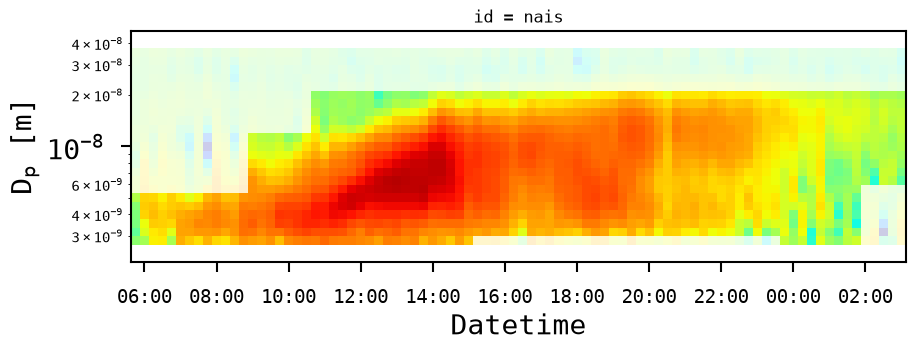

In [36]:
fig, ax = plt.subplots(figsize=(10, 3))
spectral_plot(ds_event_cleaned, var='dndlDp', x='time', title='', ax=ax)
spectral_plot(ds_event, var='dndlDp', x='time', title='', alpha=.2, ax=ax)
plt.show()

# DMPS: 

In [38]:
path = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Data\dmps\dmps_harmonized'
files = glob.glob(path+'\\*')
print(files)

['C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Data\\dmps\\dmps_harmonized\\2021_QA_QC@STP_HARMONIZED.dat', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Data\\dmps\\dmps_harmonized\\2022_QA_QC@STP_HARMONIZED.dat', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Data\\dmps\\dmps_harmonized\\2023_QA_QC@STP_HARMONIZED.dat', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Data\\dmps\\dmps_harmonized\\2024_QA_QC@STP_HARMONIZED.dat']


In [39]:
def append_data(inpath, name_in_file, all_cols, 
                datetime_cols=['YYYY', 'MM', 'DD', 'HH', 'mm']):
    DFs = []
    folder = glob.glob(inpath+'\\'+str(name_in_file)+'*.dat')
    print(folder)
    folder.sort()
    for file in folder: 
        print(file)
        ds = pd.read_csv(file, sep='\s+', 
                         skiprows=1, names=all_cols)   
        ds[datetime_cols] = ds[datetime_cols].astype(int)
        ds['DateTime'] = ds[datetime_cols].apply(lambda s : datetime(*s),axis = 1)
        ds = ds.drop(datetime_cols, axis=1)
        ds = ds.set_index('DateTime')        
        print("Size without flags removed: "+str(len(ds)))
        ds = ds[ds.loc[:,'numflag'] != 0.999] #remove these
        DFs.append(ds)
    return DFs

def concat_dfs(df_list, extras, bin_cols, flag):    
    appended_data = []
    for i in range(len(df_list)):         
        df = df_list[i]    
        appended_data.append(df)        
    appended_data = pd.concat(appended_data, sort=True)  
    appended_data = appended_data.reindex(extras + bin_cols + flag, axis=1)  
    return appended_data

def convert_df_to_ds(df, bin_cols, name=None, rename='', resample=False, resolution='h'):
    print("resolution: "+str(resolution))
    df.index.name = 'time'
    df_ = df[bin_cols].copy() #diameter is nm
    df_.columns = df_.columns.astype(float)*10**(-9)
    df_.columns.name = 'diameter'
    if resample == True:
        da = df_.stack().to_xarray().resample({'time':resolution}).mean()
    if resample == False:
        da = df_.stack().to_xarray()
    da.name=name
    ds = da.rename(rename).to_dataset()
    diameters_ = ds.diameter.values
    diameters_names = [str(np.round(x*10**9,3)) for x in diameters_]
    ds['time'] = pd.DatetimeIndex(ds['time'].values)
    ds['diameter'] = ds['diameter'].astype(float)
    return ds

<>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_5060\494761442.py:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ds = pd.read_csv(file, sep='\s+',


In [42]:
datetime_cols = ['YYYY', 'MM', 'DD', 'HH', 'mm']
extras = ['UFCPC','CPC3030', 'N_int', 'T', 'P', 'SAMPFLOW', 'DMA1_SHEAT', 'DMA2_SHEAT']

bin_col_names = ['5.0118723e-09', '5.6234133e-09', '6.3095734e-09',
       '7.0794578e-09', '7.9432823e-09', '8.9125094e-09', '1.0000000e-08',
       '1.1220185e-08', '1.2589254e-08', '1.4125375e-08', '1.5848932e-08',
       '1.7782794e-08', '1.9952623e-08', '2.2387211e-08', '2.5118864e-08',
       '2.8183829e-08', '3.1622777e-08', '3.5481339e-08', '3.9810717e-08',
       '4.4668359e-08', '5.0118723e-08', '5.6234133e-08', '6.3095734e-08',
       '7.0794578e-08', '7.9432823e-08', '8.9125094e-08', '1.0000000e-07',
       '1.1220185e-07', '1.2589254e-07', '1.4125375e-07', '1.5848932e-07',
       '1.7782794e-07', '1.9952623e-07', '2.2387211e-07', '2.5118864e-07',
       '2.8183829e-07', '3.1622777e-07', '3.5481339e-07', '3.9810717e-07',
       '4.4668359e-07', '5.0118723e-07', '5.6234133e-07', '6.3095734e-07',
       '7.0794578e-07']

bin_col_names_floats = [float(i)*10**9 for i in bin_col_names]
bin_cols = np.around(bin_col_names_floats, decimals=3)
bin_cols = np.asarray(bin_cols) 
bin_cols = [str(x) for x in bin_cols]
flag = ['numflag']
all_cols = datetime_cols + extras + bin_cols + flag

DFs_2021_2024 = append_data(path, name_in_file='', all_cols=all_cols)
Dps = [float(x) for x in bin_cols]
df_2021_2024 = concat_dfs(DFs_2021_2024, extras, bin_cols, flag)
df_2021_2024['P'] = df_2021_2024['P']*10**3

xr_dmps_30min = convert_df_to_ds(df_2021_2024, bin_cols, name=None, 
                              rename="dmps_number", resample=True, resolution='30min')

['C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Data\\dmps\\dmps_harmonized\\2021_QA_QC@STP_HARMONIZED.dat', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Data\\dmps\\dmps_harmonized\\2022_QA_QC@STP_HARMONIZED.dat', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Data\\dmps\\dmps_harmonized\\2023_QA_QC@STP_HARMONIZED.dat', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Data\\dmps\\dmps_harmonized\\2024_QA_QC@STP_HARMONIZED.dat']
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Data\dmps\dmps_harmonized\2021_QA_QC@STP_HARMONIZED.dat
Size without flags removed: 17520
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Data\dmps\dmps_harmonized\2022_QA_QC@STP_HARMONIZED.dat
Size without flags removed: 17520
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Data\dmps\dmps_harmonized\2023_QA_QC@STP_HARMONIZED.dat
Size without flags removed: 17520
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-m

In [45]:
loadpath_PLC = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\PLC'

df_dp_loss = pd.read_csv(loadpath_PLC+'\\'+'PLC.csv')
df_dp_loss.Dp = df_dp_loss.Dp.astype(str)
dict_dp_to_loss = dict(zip(df_dp_loss.Dp, df_dp_loss.Loss))

In [47]:
def correct_losses(df_DMPS, bin_cols, dict_dp_to_loss):
    df_DMPS = df_DMPS.copy()
    for bin_col in bin_cols:
        pene = (1-dict_dp_to_loss[bin_col]/100)
        df_DMPS[bin_col] = df_DMPS[bin_col]/pene
    return df_DMPS

In [48]:
df_DMPS = df_2021_2024[bin_cols]
df_DMPS_CF = correct_losses(df_DMPS, bin_cols, dict_dp_to_loss)

In [49]:
df_DMPS_CF.head(2)

,5.012,5.623,6.31,7.079,7.943,8.913,10.0,11.22,12.589,14.125,...,251.189,281.838,316.228,354.813,398.107,446.684,501.187,562.341,630.957,707.946
time,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,8.072089e-29,7.594950e-29,7.190137e-29,6.888424e-29,6.572801e-29,6.341365e-29,6.147171e-29,0.200584,3.845093,3.715055,...,15.929931,16.126947,17.750521,21.215765,12.835705,4.233152,1.266619e-01,4.294807e+00,2.707898,1.603347e-29
2021-01-01 00:30:00,8.080776e-29,7.600721e-29,2.763321e+00,9.979390e+00,2.281330e-02,6.348212e-29,2.830076e+00,5.206184,4.303593,5.753681,...,7.852383,13.864471,14.385373,8.504157,8.806541,5.845448,1.697158e-29,1.660463e-29,2.304691,5.027395e+00


In [ ]:
xr_dmps_30min = convert_df_to_ds(df_DMPS, bin_cols, name=None, 
                            rename="dmps_number", resample=True, resolution='30min')

resolution: 30min


In [51]:
xr_dmps_30min_CF = convert_df_to_ds(df_DMPS_CF, bin_cols, name=None, 
                              rename="dmps_number", resample=True, resolution='30min')

resolution: 30min


In [58]:
def prepare_xr(xr_dmps_30min, id='dmps', average='median'):
    xr_dmps = xr_dmps_30min['dmps_number'].to_pandas()
    if average == 'mean':
        ds_ = xr_dmps.stack().to_xarray().rename({'diameter':'Dp'}).assign_coords({'Dp':lambda d:d['Dp'].astype(float)}).rename('dndlDp').sortby('time').resample({'time':'60min'}).mean()
    if average == 'median':
        ds_ = xr_dmps.stack().to_xarray().rename({'diameter':'Dp'}).assign_coords({'Dp':lambda d:d['Dp'].astype(float)}).rename('dndlDp').sortby('time').resample({'time':'60min'}).median()

    ds_.drop_duplicates(dim='time')
    ds_dmps = (ds_.pipe(dp_regrid, log_dy=.05, n_subs=10).pipe(set_Dp).pipe(upsample_ts, 15*60)) 

    ds_dmps = ds_dmps.to_dataset()
    ds_dmps = ds_dmps.expand_dims({'id':[id]})
    ds_dmps = ds_dmps.drop_vars('lDp')
    ds_dmps = ds_dmps.loc[{'time':slice('2022-04-17','2024-10-04')}]
    return ds_dmps

In [59]:
ds_dmps = prepare_xr(xr_dmps_30min, id='dmps', average='median')
ds_dmps_CF = prepare_xr(xr_dmps_30min_CF, id='dmps', average='median')

original dims: ['time', 'Dp']
original dims: ['time', 'Dp']


In [64]:
savepath_NPF_events_dmps = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_dmps'

save_events(ds_dmps_CF, df_NPF_plusgrowth, id='dmps',
            savepath = savepath_NPF_events_dmps)

C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_dmps
2022-04-17T12:00:00.000000
20220417
2022-04-18T06:25:00.000000
20220418
2022-04-21T05:40:00.000000
20220421
2022-04-23T06:00:00.000000
20220423
2022-04-24T12:00:00.000000
20220424
2022-04-28T02:50:00.000000
20220428
2022-04-29T08:00:00.000000
20220429
NaT
NaT
2022-05-02T05:35:00.000000
20220502
2022-05-03T03:15:00.000000
20220503
2022-05-04T05:30:00.000000
20220504
2022-05-05T06:25:00.000000
20220505
2022-05-16T09:00:00.000000
20220516
2022-05-17T06:50:00.000000
20220517
2022-05-19T08:30:00.000000
20220519
2022-05-20T05:05:00.000000
20220520
2022-05-22T11:55:00.000000
20220522
2022-05-30T05:00:00.000000
20220530
2022-06-02T07:05:00.000000
20220602
2022-06-05T07:50:00.000000
20220605
2022-06-13T10:30:00.000000
20220613
2022-06-14T02:05:00.000000
20220614
2022-06-17T06:00:00.000000
20220617
2022-06-24T17:00:00.000000
20220624
2022-06-25T09:20:00.000000
20220625
2022-07-02T10:40:00.000000
202

C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20220502.nc
found bounds
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\bad_data_bounds_20220502.nc
Processing ROI 0
Processing ROI 1
Processing ROI 2
Processing ROI 3
Processing ROI 4


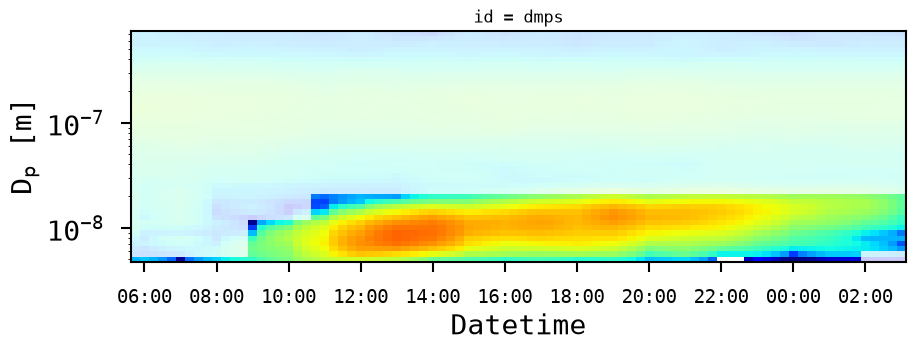

In [67]:
#bad_data_bounds_20220421
date='2022-05-02'
name = date.replace('-','')

savepath = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_dmps'
infile_bounds=r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS'

ds_event = xr.open_dataset(savepath+'\\'+str(name)+'.nc')
ds_event = slice_dim_xr(ds_event, min_dim=2e-9, max_dim = None)

ds_event_cleaned = clean_with_bounds(ds_event, date, 
                    infile_bounds=infile_bounds)

fig, ax = plt.subplots(figsize=(10, 3))
spectral_plot(ds_event_cleaned, var='dndlDp', x='time', title='', ax=ax)
spectral_plot(ds_event, var='dndlDp', x='time', title='', alpha=.2, ax=ax)
plt.show()

In [75]:
def beta(dp,temp,pres,diffusivity,molar_mass):
    """ 
    Calculate Fuchs Sutugin correction factor 

    Sutugin et al. (1971): https://doi.org/10.1016/0021-8502(71)90061-9

    Parameters
    ----------

    dp : float or numpy.array (m,)
        aerosol particle diameter(s), 
        unit: m

    temp : float or numpy.array (n,1)
        temperature, 
        unit: K

    pres : float or numpy.array (n,1)
        pressure,
        unit: Pa

    diffusivity : float or numpy.array (n,1)
        diffusivity of the gas that is condensing, 
        unit: m2/s

    molar_mass : float
        molar mass of the condensing gas, 
        unit: g/mol

    Returns
    -------

    float or numpy.array
        Fuchs Sutugin correction factor for each particle diameter and 
        temperature/pressure 
        unit: m2/s

    """

    R = 8.314 
    l = 3.*diffusivity/((8.*R*temp)/(np.pi*molar_mass*0.001))**0.5
    knud = 2.*l/dp
    
    return (1. + knud)/(1. + 1.677*knud + 1.333*knud**2)

def binary_diffusivity(temp,pres,Ma,Mb,Va,Vb):
    """ 
    Binary diffusivity in a mixture of gases a and b

    Fuller et al. (1966): https://doi.org/10.1021/ie50677a007 

    Parameters
    ----------

    temp : float or numpy.array
        temperature, 
        unit: K

    pres : float or numpy.array
        pressure, 
        unit: Pa

    Ma : float
        relative molecular mass of gas a, 
        unit: dimensionless

    Mb : float
        relative molecular mass of gas b, 
        unit: dimensionless

    Va : float
        diffusion volume of gas a, 
        unit: dimensionless

    Vb : float
        diffusion volume of gas b, 
        unit: dimensionless

    Returns
    -------

    float or numpy.array
        binary diffusivity, 
        unit: m2 s-1

    """
    
    diffusivity = (1.013e-2*(temp**1.75)*np.sqrt((1./Ma)+(1./Mb)))/(pres*(Va**(1./3.)+Vb**(1./3.))**2)
    return diffusivity

def dndlogdp2dn(df):
    """    
    Convert from normalized number concentrations to
    unnormalized number concentrations assuming that 
    the size channels have common edges.

    Parameters
    ----------

    df : pandas.DataFrame
        Aerosol number-size distribution (dN/dlogDp)

    Returns
    -------

    pandas.DataFrame
        Aerosol number size distribution (dN)

    """
    
    logdp_mid = np.log10(df.columns.values.astype(float))
    logdp = (logdp_mid[:-1]+logdp_mid[1:])/2.0
    logdp = np.append(logdp,logdp_mid.max()+(logdp_mid.max()-logdp.max()))
    logdp = np.insert(logdp,0,logdp_mid.min()-(logdp.min()-logdp_mid.min()))
    dlogdp = np.diff(logdp)

    return df*dlogdp

def calc_cs(df,temp,pres):
    """
    Calculate condensation sink, assuming that the condensing gas is sulfuric acid in air
    with aerosol particles.

    Kulmala et al (2012): doi:10.1038/nprot.2012.091 

    Parameters
    ----------

    df : pandas.DataFrame
        aerosol number size distribution (dN/dlogDp)

    temp : pandas.DataFrame or float
        Ambient temperature corresponding to the data, unit: K
        If single value given it is used for all data

    pres : pandas.DataFrame or float
        Ambient pressure corresponding to the data, unit: Pa
        If single value given it is used for all data

    Returns
    -------
    
    pandas.Series
        condensation sink time series, unit: s-1

    """
    
    if isinstance(temp,float):
        temp = pd.DataFrame(index = df.index, columns=["Temperature"], data=temp)
    else:
        temp = temp.reindex(df.index, method="nearest")

    if isinstance(pres,float):
        pres = pd.DataFrame(index = df.index, columns=["Pressure"], data=pres)
    else:
        pres = pres.reindex(df.index, method="nearest")

    M_h2so4 = 98.08   
    M_air = 28.965    
    V_air = 19.7      
    V_h2so4 = 51.96  

    dn = dndlogdp2dn(df)

    dp = df.columns.values.astype(float)

    diffu = binary_diffusivity(temp.values,pres.values,M_h2so4,M_air,V_h2so4,V_air)

    b = beta(dp,temp.values,pres.values,diffu,M_h2so4)

    df2 = (1e6*dn*(b*dp)).sum(axis=1,min_count=1)

    cs = (4.*np.pi*diffu.flatten())*df2.values

    return pd.Series(index=df.index,data=cs)

In [76]:
df_event_cleaned = ds_event_cleaned['dndlDp'].to_pandas()
Dps = list(df_event_cleaned.columns)

df_event_cleaned_T = df_event_cleaned.merge(df_2021_2024[['T']], left_index=True, right_index=True, how='left')
df_event_cleaned_T_P = df_event_cleaned_T.merge(df_2021_2024[['P']], left_index=True, right_index=True, how='left')

df_condensation_sink_event = calc_cs(df_event_cleaned_T_P[Dps], temp=df_2021_2024[['T']], 
                                   pres=df_2021_2024[['P']])
df_CS_event = df_condensation_sink_event.to_frame(name='CS')
df_CS_event_hourly = df_CS_event.resample('h').mean()
df_CS_event_hourly = df_CS_event_hourly.dropna(how='all')

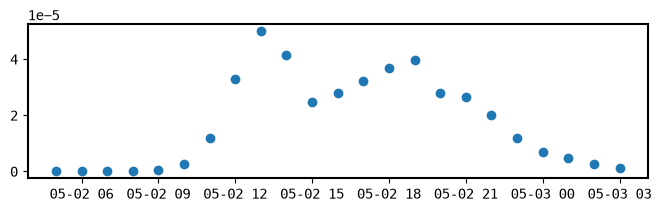

In [77]:
fig, ax = plt.subplots(figsize=(8, 2))
ax.plot(df_CS_event_hourly.index, df_CS_event_hourly['CS'].values, 'o')
plt.show()

In [92]:
#bad_data_bounds_20220421
date='2022-05-02'

NPF_events_dmps_loadpath = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_dmps'
infile_bounds=r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS'

def get_ds_event(date, loadpath, infile_bounds, select_mode=True):
    name = date.replace('-','')
    ds_event = xr.open_dataset(loadpath+'\\'+str(name)+'.nc')
    ds_event = slice_dim_xr(ds_event, min_dim=None, max_dim = None)
    if select_mode == True:
        ds_event = clean_with_bounds(ds_event, date, 
                            infile_bounds=infile_bounds)
    return ds_event

def get_event_files(event_days, files):
    files_list = []
    for event in event_days:
        string_event = str(event)[:10].replace('-','')
        digit_files = [get_digits(x) for x in files]
        index = digit_files.index(string_event)
        file = files[index]
        files_list.append(file)
    return files_list

def get_digits(string_with_digits, digit_order=2):
    digit = re.findall(r'\d+', string_with_digits)[digit_order]
    return digit

In [87]:
dalmaso_class_loadpath = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\DalMaso_classification'
dalmaso_filename = 'ZEP_class_DalMaso.txt'

ZEP_class = pd.read_csv(dalmaso_class_loadpath+'\\'+dalmaso_filename, index_col=0, 
                        parse_dates=True)
df_classIa = ZEP_class[ZEP_class['Class Ia'].notnull()]
df_classIb = ZEP_class[ZEP_class['Class Ib'].notnull()]
df_classII = ZEP_class[ZEP_class['Class II'].notnull()]

print(len(df_classIa))
print(len(df_classIb))
print(len(df_classII))

print("total number: ")
print(len(df_classIa)+len(df_classIb)+len(df_classII))

df_classUndefined = ZEP_class[ZEP_class['Undefined'].notnull()]
df_classNonE = ZEP_class[ZEP_class['Non-event'].notnull()]

dict_name_to_df = {}
dict_name_to_df['Class Ia'] = df_classIa
dict_name_to_df['Class Ib'] = df_classIb
dict_name_to_df['Class II'] = df_classII
dict_name_to_df['Undefined'] = df_classUndefined 
dict_name_to_df['Non-event'] = df_classNonE

event_days = list(df_classIa.index.unique())+list(df_classIb.index.unique())+list(df_classII.index.unique())

event_days = sorted(event_days)
event_days = [pd.to_datetime(str(x)) for x in event_days]

ZEP_inpath_files = r"C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\ZEP_processed_files"
files = glob.glob(ZEP_inpath_files+'\\*.nc')
event_files = get_event_files(event_days, files)

27
19
109
total number: 
155


In [88]:
def add_hours(df_CS_event_hourly):
    df_CS_event_hourly['hour'] = df_CS_event_hourly.index.hour
    num_dates = len(np.unique(df_CS_event_hourly.index.date))
    print(num_dates)
    for i in range(num_dates):
        print(i)
        df_CS_event_hourly['day'] = df_CS_event_hourly.index.day
        day = df_CS_event_hourly.index.day[0] 
        df_CS_event_hourly['day'] = df_CS_event_hourly['day'] - day
        df_CS_event_hourly['day_hour'] = df_CS_event_hourly['day']*24
    return df_CS_event_hourly

In [89]:
loadpath = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_dmps'

event_files = glob.glob(loadpath+'\*')
event_files_dates = [str(x).replace(loadpath+'\\','').replace('.nc','') for x in event_files]

<>:3: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<>:3: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_5060\125115916.py:3: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
  event_files = glob.glob(loadpath+'\*')


In [93]:
loadpath = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_dmps'

event_files = glob.glob(loadpath+'\*')
print(event_files)
event_files_dates = [str(x).replace(loadpath+'\\','').replace('.nc','') for x in event_files]
print(event_files_dates)

['C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_dmps\\20220417.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_dmps\\20220418.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_dmps\\20220421.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_dmps\\20220423.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_dmps\\20220424.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_dmps\\20220428.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_dmps\\20220429.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_dmps\\20220502.nc', 'C:\\Users\\Dell\\Docum

<>:3: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
<>:3: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_5060\1167093609.py:3: SyntaxWarning: "\*" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\*"? A raw string is also an option.
  event_files = glob.glob(loadpath+'\*')


2022-04-18
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20220418.nc
found bounds
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\bad_data_bounds_20220418.nc
Processing ROI 0
Processing ROI 1
Processing ROI 2
2
0
1
Index(['CS', 'hour', 'day', 'day_hour'], dtype='str')
                               CS  hour  day  day_hour
time                                                  
2022-04-18 06:00:00  5.744308e-09     6    0         0
2022-04-18 07:00:00  9.533982e-09     7    0         0
2022-04-18 08:00:00  1.292447e-08     8    0         0
2022-04-18 09:00:00  1.414361e-08     9    0         0
2022-04-18 10:00:00  4.411334e-08    10    0         0
2022-04-18 11:00:00  1.086446e-05    11    0         0
2022-04-18 12:00:00  1.301610e-05    12    0         0
2022-04-18 13:00:00  9.689366e-06    13    0         0
2022-04-18 14:00:00  9.300717e-06    14    0         0

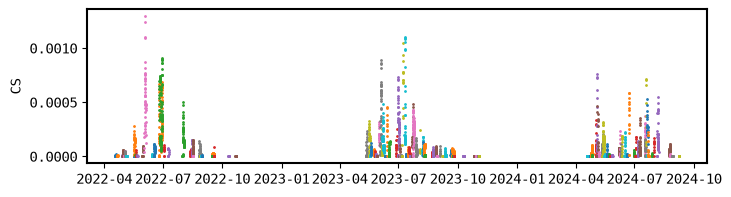

In [ ]:
fig, ax = plt.subplots(figsize=(8, 2))

list_dfs = []
list_dfs_times = []

for event_day in event_days:
    date = str(event_day.date()) 
    print(date)  
    if str(date).replace('-','') in event_files_dates:
        ds_event_cleaned = get_ds_event(date, loadpath, infile_bounds)
        df_event_cleaned = ds_event_cleaned['dndlDp'].to_pandas()
        Dps = list(df_event_cleaned.columns)

        df_event_cleaned_T = df_event_cleaned.merge(df_2021_2024[['T']], left_index=True, right_index=True, how='left')
        df_event_cleaned_T_P = df_event_cleaned_T.merge(df_2021_2024[['P']], left_index=True, right_index=True, how='left')

        df_condensation_sink_event = calc_cs(df_event_cleaned_T_P[Dps], temp=df_event_cleaned_T_P[['T']], 
                                    pres=df_event_cleaned_T_P[['P']])        
        df_CS_event = df_condensation_sink_event.to_frame(name='CS')

        if len(df_CS_event) > 0:
            df_CS_event_hourly = df_CS_event.resample('h').mean()
            df_CS_event_hourly = df_CS_event_hourly.dropna(how='all')            
            ax.plot(df_CS_event_hourly.index, df_CS_event_hourly['CS'].values, 'o', ms=1,)
            list_dfs_times.append(df_CS_event_hourly)
            df_CS_event_hourly = add_hours(df_CS_event_hourly)        
            print(df_CS_event_hourly.columns)
            if 'day_hour' in list(df_CS_event_hourly.columns):
                df_CS_event_hourly['hour'] = df_CS_event_hourly['day_hour']+df_CS_event_hourly['hour']
            
            df = df_CS_event_hourly[['CS', 'hour']].set_index('hour')
            list_dfs.append(df)
        if len(df_CS_event) == 0:
            pass

ax.set_ylabel('CS')
plt.show()

In [96]:
df_concat = pd.concat(list_dfs, axis=1).sort_index()
df_concat = df_concat[df_concat.index >= 0]

In [ ]:
CS_file = 'CS.dat'
CS_loadpath = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\back_trajectories_data\CS_solar_negparticles'
df_CS_mode = pd.concat(list_dfs_times)
df_CS_mode = df_CS_mode.rename(columns={'CS': 'CS_mode'})

df_CS_hourly = pd.read_csv(CS_loadpath+'\\'+CS_file, index_col=0, parse_dates=True)
df_CS_hourly_mode = df_CS_hourly.merge(df_CS_mode, left_index=True, right_index=True, how='left')

df_CS_hourly_mode['propotion'] = df_CS_hourly_mode['CS_mode']/df_CS_hourly_mode['CS']

In [101]:
df_CS_hourly_mode_D = df_CS_hourly_mode.resample('D').mean()
df_CS_hourly_mode_M = df_CS_hourly_mode.resample('ME').mean()

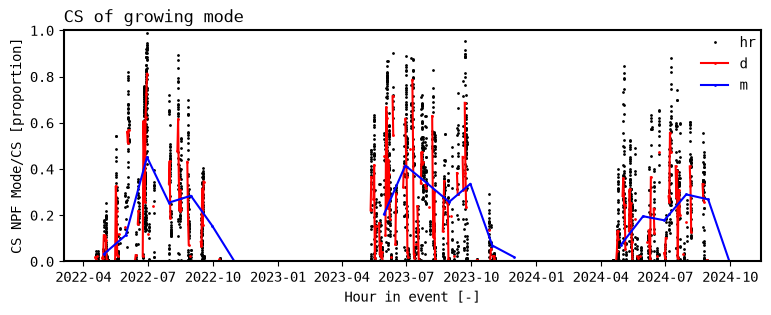

In [105]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(df_CS_hourly_mode.index, df_CS_hourly_mode['propotion'], 'o', ms=1, c='k', label='hr')
ax.plot(df_CS_hourly_mode_D.index, df_CS_hourly_mode_D['propotion'], 'o-', ms=1, c='r', label='d')
ax.plot(df_CS_hourly_mode_M.index, df_CS_hourly_mode_M['propotion'], 'o-', ms=1, c='b', label='m')
ax.legend(loc=3, frameon=False)
ax.set_ylabel('CS NPF Mode/CS [proportion]')
ax.set_xlabel('Hour in event [-]')
ax.set_title('CS of growing mode', loc='left')
plt.legend(bbox_to_anchor=(1, 1), borderaxespad=0, frameon=False)
ax.set_ylim(0, 1)
plt.show()

In [106]:
df_groupby_mean = df_concat.mean(axis=1)
df_groupby_median = df_concat.median(axis=1)
df_groupby_25 = df_concat.quantile(q=0.25, axis=1)
df_groupby_75 = df_concat.quantile(q=0.75, axis=1)

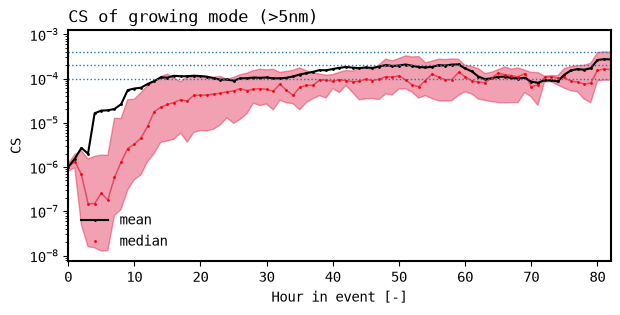

In [107]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(df_groupby_mean.index, df_groupby_mean, 'o-', ms=1, c='k', label='mean')
ax.plot(df_groupby_median.index, df_groupby_median, 'o', ms=1, c='r', label='median')

ax.fill_between(df_groupby_mean.index, df_groupby_median, df_groupby_25, color="crimson", alpha=0.4)
ax.fill_between(df_groupby_mean.index, df_groupby_75, df_groupby_median, color="crimson", alpha=0.4)

ax.legend(loc=3, frameon=False)

ax.axhline(y=0.4*10**(-3),xmin=0, xmax=140, lw=1, ls=':')
ax.axhline(y=0.2*10**(-3),xmin=0, xmax=140, lw=1, ls=':')
ax.axhline(y=0.1*10**(-3),xmin=0, xmax=140, lw=1, ls=':')

ax.set_xlim(0, 82)

ax.set_ylabel('CS')
ax.set_yscale('log')
ax.set_xlabel('Hour in event [-]')
ax.set_title('CS of growing mode (>5nm)', loc='left')
plt.show()

In [114]:
def read_in_growth_excel(event_times_loadpath,
                        filename='events_start_and_end_times_checked.xlsx'):
    df_NPF_plusgrowth = pd.read_excel(event_times_loadpath+'\\'+filename, index_col=0, parse_dates=True)
    df_NPF_plusgrowth.index.name = 'event'
    df_NPF_plusgrowth['start_date'] = df_NPF_plusgrowth['start_event'].dt.date
    df_NPF_plusgrowth['start_date'] = df_NPF_plusgrowth['start_date'].astype(str)
    df_NPF_plusgrowth['end_date'] = df_NPF_plusgrowth['end_event'].dt.date
    df_NPF_plusgrowth['end_date'] = df_NPF_plusgrowth['end_date'].astype(str)
    return df_NPF_plusgrowth

In [119]:
def get_times_removed_duplicates(df_NPF_plusgrowth, start_col='start_event', end_col='end_event', 
                                 freq='15min', new_colname='NPF_growth'):
    timespans = []
    for i in range(len(df_NPF_plusgrowth)):
        try:
            start = df_NPF_plusgrowth[start_col].iloc[i]
            end = df_NPF_plusgrowth[end_col].iloc[i]
            timespan = pd.date_range(start,end,freq='15min')
            timespans.append(timespan)
        except:
            pass
    timespans = flatten(timespans)
    timespans = [str(x) for x in timespans]
    df_NPF_growth = pd.DataFrame(timespans, columns=['datetime'])
    df_NPF_growth[new_colname] = 1
    df_NPF_growth = df_NPF_growth.set_index('datetime')
    df_NPF_growth = df_NPF_growth[~df_NPF_growth.index.duplicated(keep='first')]
    df_NPF_growth.index = pd.to_datetime(df_NPF_growth.index)    
    return df_NPF_growth

def flatten(xss):
    return [x for xs in xss for x in xs]

In [ ]:
df_CS_hourly = pd.read_csv(CS_loadpath+'\\'+CS_file, index_col=0, parse_dates=True)

df_NPF_plusgrowth = read_in_growth_excel(event_times_loadpath)
df_NPF_growth = get_times_removed_duplicates(df_NPF_plusgrowth)
NPF_growth_datetime_list = df_NPF_growth.index

df_NPF_growth = df_NPF_growth.resample('h').mean()
df_NPF_growth = df_NPF_growth.copy()
df_NPF_growth = df_NPF_growth[df_NPF_growth['NPF_growth'] == 1]

In [123]:
df_CS_hourly_NPF_growth = df_CS_hourly.merge(df_NPF_growth, left_index=True, right_index=True, how='right')

In [ ]:
def run_for_all_events(loadpath, infile_bounds):
    fig, ax = plt.subplots(figsize=(8, 2))
    list_dfs = []
    list_dfs_times = []
    event_files = glob.glob(loadpath+'\\*')
    print(event_files)
    event_files_dates = [str(x).replace(loadpath+'\\','').replace('.nc','') for x in event_files]
    for event_day in event_days:
        date = str(event_day.date()) 
        print(date)  
        if str(date).replace('-','') in event_files_dates:
            ds_event_cleaned = get_ds_event(date, loadpath, infile_bounds, select_mode=False)
            df_event_cleaned = ds_event_cleaned['dndlDp'].to_pandas()
            Dps = list(df_event_cleaned.columns)
            df_event_cleaned_T = df_event_cleaned.merge(df_2021_2024[['T']], left_index=True, right_index=True, how='left')
            df_event_cleaned_T_P = df_event_cleaned_T.merge(df_2021_2024[['P']], left_index=True, right_index=True, how='left')
            df_condensation_sink_event = calc_cs(df_event_cleaned_T_P[Dps], temp=df_event_cleaned_T_P[['T']], 
                                        pres=df_event_cleaned_T_P[['P']])            
            df_CS_event = df_condensation_sink_event.to_frame(name='CS')
            if len(df_CS_event) > 0:
                df_CS_event_hourly = df_CS_event.resample('h').mean()
                df_CS_event_hourly = df_CS_event_hourly.dropna(how='all')                
                ax.plot(df_CS_event_hourly.index, df_CS_event_hourly['CS'].values, 'o', ms=1,)
                list_dfs_times.append(df_CS_event_hourly)                  
                df_CS_event_hourly = add_hours(df_CS_event_hourly)        
                print(df_CS_event_hourly.columns)
                if 'day_hour' in list(df_CS_event_hourly.columns):
                    df_CS_event_hourly['hour'] = df_CS_event_hourly['day_hour']+df_CS_event_hourly['hour']
                df = df_CS_event_hourly[['CS', 'hour']].set_index('hour')
                list_dfs.append(df)
            if len(df_CS_event) == 0:
                pass
    ax.set_ylabel('CS')
    plt.show()
    return list_dfs

['C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_dmps\\20220417.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_dmps\\20220418.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_dmps\\20220421.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_dmps\\20220423.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_dmps\\20220424.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_dmps\\20220428.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_dmps\\20220429.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_dmps\\20220502.nc', 'C:\\Users\\Dell\\Docum

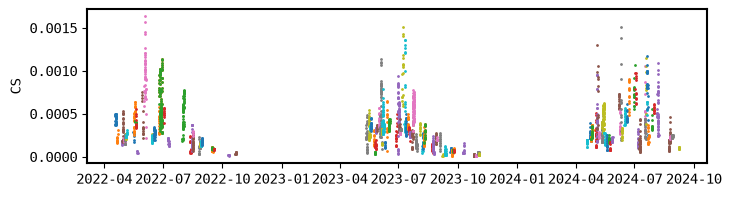

In [133]:
npf_dmps_loadpath = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_dmps'

list_dfs_all = run_for_all_events(npf_dmps_loadpath, infile_bounds)
df_concat_all = pd.concat(list_dfs_all, axis=1).sort_index()
df_concat_all = df_concat_all[df_concat_all.index >= 0]

In [134]:
df_groupby_mean_all = df_concat_all.mean(axis=1)
df_groupby_median_all = df_concat_all.median(axis=1)
df_groupby_25_all = df_concat_all.quantile(q=0.25, axis=1)
df_groupby_75_all = df_concat_all.quantile(q=0.75, axis=1)

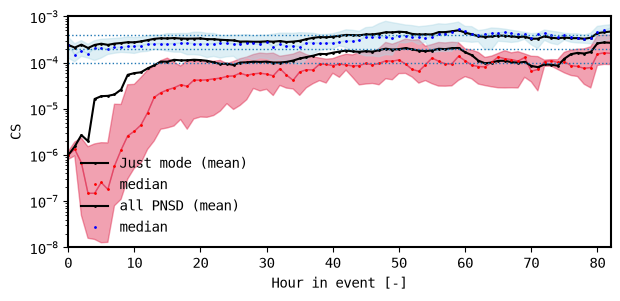

In [135]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(df_groupby_mean.index, df_groupby_mean, 'o-', ms=1, c='k', label='Just mode (mean)')
ax.plot(df_groupby_median.index, df_groupby_median, 'o', ms=1, c='r', label='median')

ax.fill_between(df_groupby_mean.index, df_groupby_median, df_groupby_25, color="crimson", alpha=0.4)
ax.fill_between(df_groupby_mean.index, df_groupby_75, df_groupby_median, color="crimson", alpha=0.4)

ax.plot(df_groupby_mean_all.index, df_groupby_mean_all, 'o-', ms=1, c='k', label='all PNSD (mean)')
ax.plot(df_groupby_median_all.index, df_groupby_median_all, 'o', ms=1, c='b', label='median')
ax.fill_between(df_groupby_mean_all.index, df_groupby_median_all, df_groupby_25_all, color="lightblue", alpha=0.4)
ax.fill_between(df_groupby_mean_all.index, df_groupby_75_all, df_groupby_median_all, color="lightblue", alpha=0.4)

ax.legend(loc=3, frameon=False)

ax.axhline(y=0.4*10**(-3),xmin=0, xmax=140, lw=1, ls=':')
ax.axhline(y=0.2*10**(-3),xmin=0, xmax=140, lw=1, ls=':')
ax.axhline(y=0.1*10**(-3),xmin=0, xmax=140, lw=1, ls=':')

ax.set_ylim(10**(-8), 10**(-3))

ax.set_xlim(0, 82)

ax.set_ylabel('CS')
ax.set_yscale('log')
ax.set_xlabel('Hour in event [-]')
#ax.set_title('CS of growing mode (>5nm)', loc='left')
plt.show()

In [142]:
def growth_of_CS(df_groupby_mean_all, df_groupby_median_all, df_groupby_25_all, df_groupby_75_all):
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(df_groupby_mean_all.index, df_groupby_mean_all, 'o-', ms=1, c='k', label='all PNSD (mean)')
    ax.plot(df_groupby_median_all.index, df_groupby_median_all, 'o', ms=1, c='b', label='median')
    ax.fill_between(df_groupby_mean_all.index, df_groupby_median_all, df_groupby_25_all, color="lightblue", alpha=0.4)
    ax.fill_between(df_groupby_mean_all.index, df_groupby_75_all, df_groupby_median_all, color="lightblue", alpha=0.4)

    ax.legend(loc=3, frameon=False)

    ax.axhline(y=0.6*10**(-3),xmin=0, xmax=140, lw=1, ls=':')
    ax.axhline(y=0.4*10**(-3),xmin=0, xmax=140, lw=1, ls=':')
    ax.axhline(y=0.2*10**(-3),xmin=0, xmax=140, lw=1, ls=':')
    ax.axhline(y=0.1*10**(-3),xmin=0, xmax=140, lw=1, ls=':')

    trans = ax.get_yaxis_transform() #y coord are axes
    ax.text(0.85, 0.2*10**(-3), '0.2$\cdot$10$^{-3}$', transform=trans)
    ax.text(0.85, 0.6*10**(-3), '0.6$\cdot$10$^{-3}$', transform=trans)

    # ax.set_ylim(10**(-4), 1.1*10**(-3))
    ax.set_xlim(0, 82)

    ax.set_ylabel('CS [s$^{-1}$]')
    ax.set_yscale('log')
    ax.set_xlabel('Hour in event [-]')
    plt.show()
    return fig

<>:16: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:17: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:16: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:17: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_5060\2070599530.py:16: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  ax.text(0.85, 0.2*10**(-3), '0.2$\cdot$10$^{-3}$', transform=trans)
C:\Users\Dell\AppData\Local\Temp\ipykernel_5060\2070599530.py:17: SyntaxWarning: "\c" is an invalid e

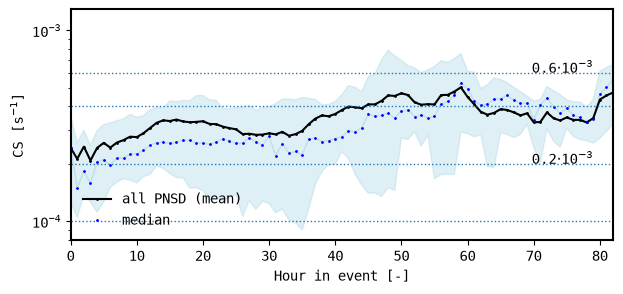

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_13.jpeg


In [148]:
fig = growth_of_CS(df_groupby_mean_all, df_groupby_median_all, df_groupby_25_all, df_groupby_75_all)

output_figure = plots_outpath / 'Figure_13.jpeg'
save_plot(fig, output_figure)

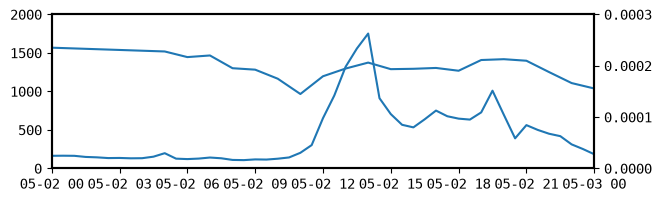

In [137]:
fig, ax = plt.subplots(figsize=(7,2))
time = df_2021_2024['N_int'].index
N_int = df_2021_2024['N_int'].values
ax.plot(time, N_int)
ax.set_ylim(0, 2000)
ax2 = ax.twinx()
time2 = df_CS_hourly_NPF_growth.index
CS = df_CS_hourly_NPF_growth['CS'].values
ax2.plot(time2, CS)
ax2.set_ylim(0, 0.0003)
ax.set_xlim(pd.to_datetime('2022-05-02 00:00:00'), pd.to_datetime('2022-05-03 00:00:00'))
plt.show()